# Notebook 04 — Evaluation
Computes all metrics and generates cross-layer comparison plots.

Metrics:
- Reconstruction MSE and L0 sparsity (from training logs)
- Dead feature rate
- CLIP interpretability score (mean cosine similarity of top label)
- Cross-layer label distribution comparison

In [1]:
import sys
sys.path.insert(0, '..')
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

ckpt4   = torch.load('../checkpoints/sae_layer4.pt',  weights_only=False)
ckpt8   = torch.load('../checkpoints/sae_layer8.pt',  weights_only=False)
ckpt12  = torch.load('../checkpoints/sae_layer12.pt', weights_only=False)
labels4  = torch.load('../checkpoints/labels_layer4.pt',  weights_only=False)
labels8  = torch.load('../checkpoints/labels_layer8.pt',  weights_only=False)
labels12 = torch.load('../checkpoints/labels_layer12.pt', weights_only=False)
raw4   = torch.load('../checkpoints/raw_labels_layer4.pt',  weights_only=False)
raw8   = torch.load('../checkpoints/raw_labels_layer8.pt',  weights_only=False)
raw12  = torch.load('../checkpoints/raw_labels_layer12.pt', weights_only=False)
log4  = ckpt4['log']
log8  = ckpt8['log']
log12 = ckpt12['log']

In [2]:
def last(log, key): return log[key][-1]
def sep(lbls): return lbls.get('sep_scores', lbls.get('corr_scores'))

rows = [
    ('Final MSE',              last(log4,'mse'),  last(log8,'mse'),  last(log12,'mse')),
    ('Final L0',               last(log4,'l0'),   last(log8,'l0'),   last(log12,'l0')),
    ('Dead feature %',         last(log4,'dead_pct'), last(log8,'dead_pct'), last(log12,'dead_pct')),
    ('SAE mean CLIP cos',      np.mean(labels4['scores']), np.mean(labels8['scores']), np.mean(labels12['scores'])),
    ('SAE mean separation',    np.mean(sep(labels4)), np.mean(sep(labels8)), np.mean(sep(labels12))),
    ('Raw neuron separation',  np.mean(sep(raw4)),    np.mean(sep(raw8)),    np.mean(sep(raw12))),
]
print(f"{'Metric':<28} {'Layer 4':>10} {'Layer 8':>10} {'Layer 12':>10}")
print('-' * 60)
for name, v4, v8, v12 in rows:
    print(f'{name:<28} {v4:>10.4f} {v8:>10.4f} {v12:>10.4f}')

Metric                          Layer 4    Layer 8   Layer 12
------------------------------------------------------------
Final MSE                        0.3838     0.4248     0.4481
Final L0                        55.9277    44.6333    38.9424
Dead feature %                   0.0000     0.0000     0.0000
SAE mean CLIP cos                0.2930     0.2935     0.2944
SAE mean separation              0.0321     0.0676     0.0616
Raw neuron separation            0.0566     0.0501     0.0354


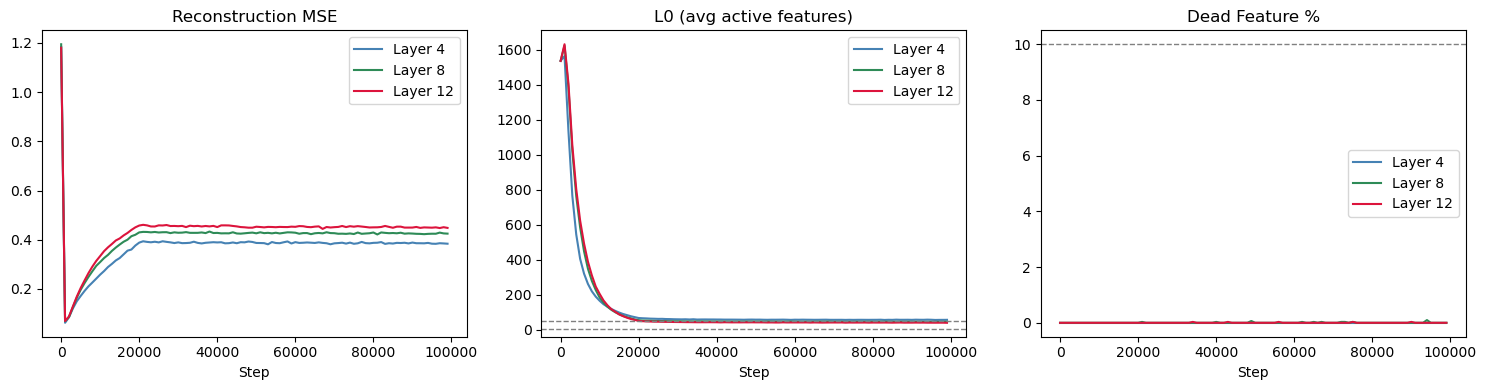

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for log, label, color in [(log4, 'Layer 4', 'steelblue'), (log8, 'Layer 8', 'seagreen'), (log12, 'Layer 12', 'crimson')]:
    s = log['step']
    axes[0].plot(s, log['mse'],      label=label, color=color)
    axes[1].plot(s, log['l0'],       label=label, color=color)
    axes[2].plot(s, log['dead_pct'], label=label, color=color)
axes[1].axhline(y=5,  color='gray', linestyle='--', linewidth=1)
axes[1].axhline(y=50, color='gray', linestyle='--', linewidth=1)
axes[2].axhline(y=10, color='gray', linestyle='--', linewidth=1)
for ax, title in zip(axes, ['Reconstruction MSE', 'L0 (avg active features)', 'Dead Feature %']):
    ax.set_title(title); ax.set_xlabel('Step'); ax.legend()
plt.tight_layout()
plt.savefig('../checkpoints/training_curves.png', dpi=150)
plt.show()

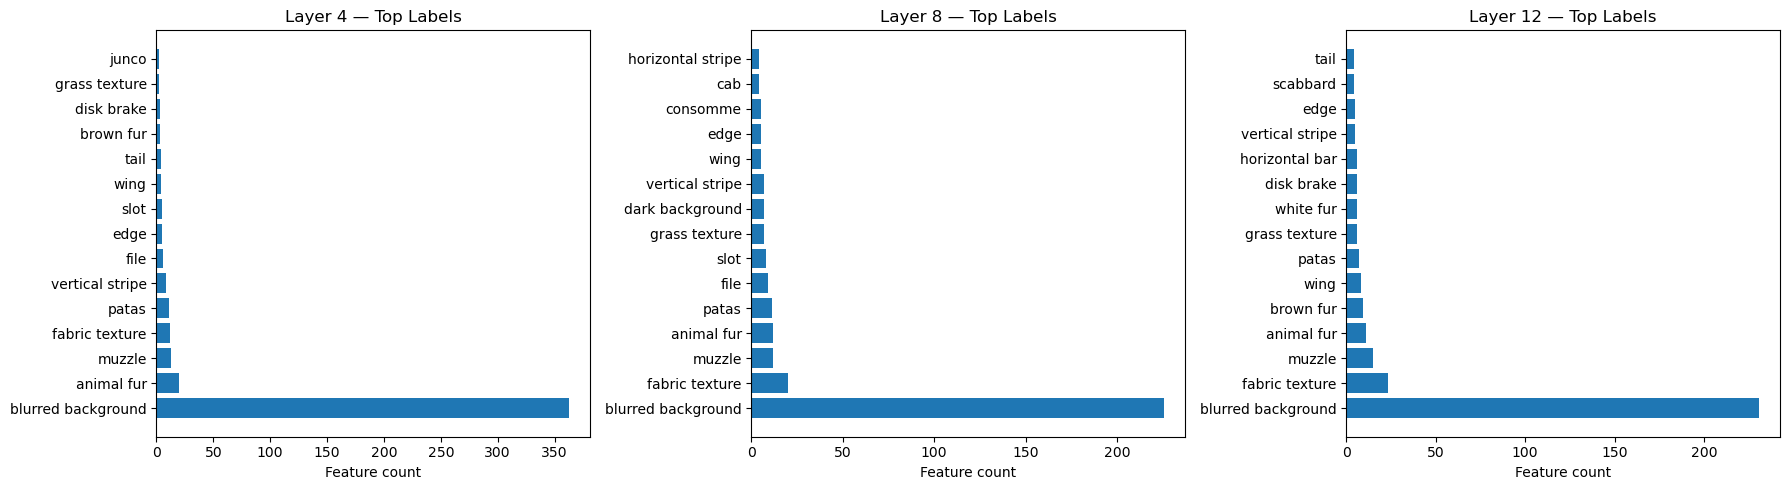

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lbls, title in [(axes[0], labels4, 'Layer 4'),
                         (axes[1], labels8, 'Layer 8'),
                         (axes[2], labels12, 'Layer 12')]:
    top15 = Counter(lbls['labels']).most_common(15)
    words, counts = zip(*top15)
    ax.barh(words, counts)
    ax.set_title(f'{title} — Top Labels')
    ax.set_xlabel('Feature count')
plt.tight_layout()
plt.savefig('../checkpoints/label_distribution.png', dpi=150)
plt.show()

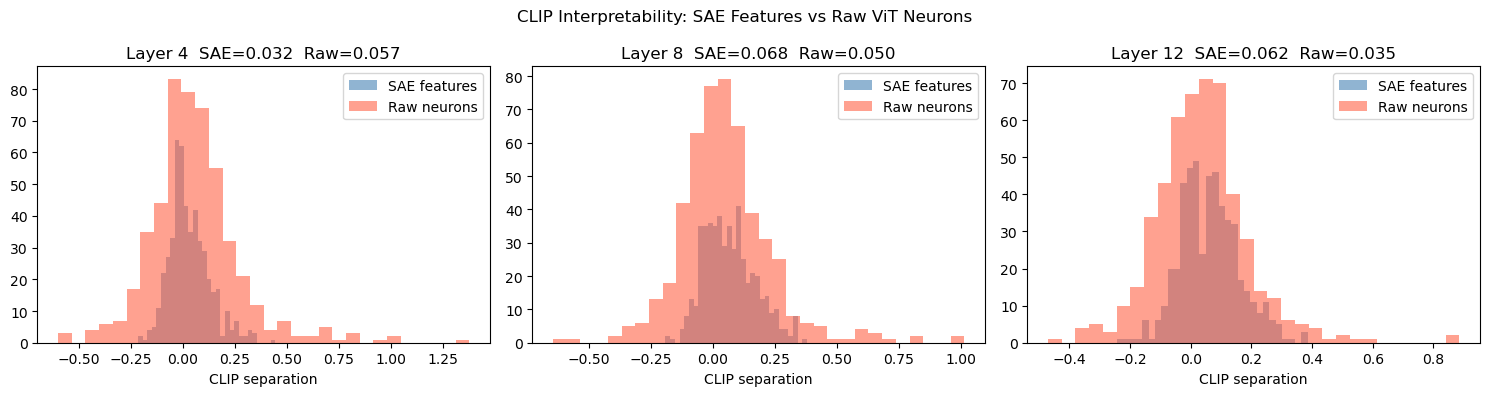

In [5]:
# SAE features vs raw ViT neurons: top-vs-bottom CLIP separation distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sae_lbls, raw_lbls, title in [
        (axes[0], labels4,  raw4,  'Layer 4'),
        (axes[1], labels8,  raw8,  'Layer 8'),
        (axes[2], labels12, raw12, 'Layer 12')]:
    sae_sep = sep(sae_lbls)
    raw_sep = sep(raw_lbls)
    ax.hist(sae_sep, bins=30, alpha=0.6, label='SAE features', color='steelblue')
    ax.hist(raw_sep, bins=30, alpha=0.6, label='Raw neurons',  color='tomato')
    ax.set_title(f'{title}  SAE={np.mean(sae_sep):.3f}  Raw={np.mean(raw_sep):.3f}')
    ax.set_xlabel('CLIP separation')
    ax.legend()
plt.suptitle('CLIP Interpretability: SAE Features vs Raw ViT Neurons', fontsize=12)
plt.tight_layout()
plt.savefig('../checkpoints/sae_vs_raw.png', dpi=150)
plt.show()

In [6]:
from pathlib import Path
from IPython.display import clear_output, display
from torchvision import datasets
from torchvision import transforms as T
from PIL import Image
import os
from src.sae import SAE
from src.clip_labeler import crop_patch

IMAGENET_VAL_DIR = r"D:\Master Material\XAI\XAI_project\archive\imagenet-val"
N_EVAL_FEATURES  = 10      # per layer; keep this small for human rating
N_SAMPLE_TOKENS  = 50000
TOP_PATCHES      = 10
HUMAN_EVAL_DIR   = Path('../checkpoints/human_eval_grids')
HUMAN_EVAL_DIR.mkdir(parents=True, exist_ok=True)

dataset          = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=None)
selected_indices = torch.load('../data/selected_indices.pt', weights_only=True)
pil_transform    = T.Compose([T.Resize(256), T.CenterCrop(224)])
HUMAN_EVAL_STATE = {}

def get_patch(orig_patch_idx, context=64):
    """Retrieve the 64x64 crop for a patch-only token index."""
    img_pos    = orig_patch_idx // 196
    tok_off    = orig_patch_idx % 196 + 1  # original tok_offset 1-196
    actual_idx = int(selected_indices[img_pos])
    img = Image.open(dataset.imgs[actual_idx][0]).convert('RGB')
    img = pil_transform(img)
    return crop_patch(img, tok_off, context)

print(f'Dataset: {len(dataset.imgs)} images, {len(selected_indices)} selected')
print(f'Human-eval grids will be saved to: {HUMAN_EVAL_DIR.resolve()}')

Dataset: 50000 images, 10000 selected
Human-eval grids will be saved to: D:\Master Material\XAI\XAI_project\xai-vit-sae\checkpoints\human_eval_grids


In [ ]:
def _random_seed():
    return int.from_bytes(os.urandom(8), 'little') % (2**63 - 1)


def _selected_feature_top_patches(
    acts_path,
    ckpt_path,
    feature_ids,
    sample_tokens=N_SAMPLE_TOKENS,
    seed=None,
):
    acts = torch.load(acts_path, weights_only=False)
    patch_mask = torch.arange(acts.shape[0]) % 197 != 0
    acts = acts[patch_mask]

    seed = _random_seed() if seed is None else int(seed)
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(acts.shape[0], generator=g)[:sample_tokens]

    ckpt = torch.load(ckpt_path, weights_only=False)
    acts_sample = (acts[idx] - ckpt['acts_mean']) / ckpt['acts_rms']

    sae = SAE(d_input=768, d_hidden=3072)
    sae.load_state_dict(ckpt['state_dict'])
    sae.eval()

    feature_ids = torch.tensor(feature_ids, dtype=torch.long)
    selected_parts = []
    chunk = 4096
    with torch.no_grad():
        for start in range(0, acts_sample.shape[0], chunk):
            f, _ = sae(acts_sample[start:start + chunk])
            selected_parts.append(f[:, feature_ids])
    selected_acts = torch.cat(selected_parts, dim=0)

    top_patches = {}
    for local_i, feat_i in enumerate(feature_ids.tolist()):
        vals = selected_acts[:, local_i]
        top = vals.topk(min(TOP_PATCHES, vals.numel())).indices.tolist()
        top_patches[feat_i] = [idx[p].item() for p in top]
    return top_patches, seed


def _sample_feature_ids(labels_data, n_features, seed):
    n_available = len(labels_data['labels'])
    n_features = min(n_features, n_available)
    perm = torch.randperm(
        n_available, generator=torch.Generator().manual_seed(seed)
    )
    return perm[:n_features].tolist()


def _save_human_ratings():
    records = HUMAN_EVAL_STATE.get('records', [])
    ratings4 = {
        r['feature']: r['rating']
        for r in records
        if r['layer'] == 'Layer 4' and r.get('rating') is not None
    }
    ratings8 = {
        r['feature']: r['rating']
        for r in records
        if r['layer'] == 'Layer 8' and r.get('rating') is not None
    }
    ratings12 = {
        r['feature']: r['rating']
        for r in records
        if r['layer'] == 'Layer 12' and r.get('rating') is not None
    }
    torch.save(
        {
            'ratings4': ratings4,
            'ratings8': ratings8,
            'ratings12': ratings12,
            'records': records,
            'session_seed': HUMAN_EVAL_STATE.get('session_seed'),
        },
        '../checkpoints/human_ratings.pt',
    )


def _show_item(item):
    patches = [
        get_patch(orig_i)
        for orig_i in item['orig_patch_indices']
        if orig_i // 196 < len(selected_indices)
    ]

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(
        f"{item['layer']} | Feature {item['feature']} | "
        f"CLIP: \"{item['label']}\" (score={item['score']:.3f})",
        fontsize=11,
    )
    for ax in axes.flat:
        ax.axis('off')
    for ax, patch in zip(axes.flat, patches):
        ax.imshow(patch)
    plt.tight_layout()

    out_path = HUMAN_EVAL_DIR / (
        f"{item['layer'].lower().replace(' ', '')}_feature_{item['feature']}.png"
    )
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    item['path'] = str(out_path)

    clear_output(wait=True)
    pos = HUMAN_EVAL_STATE['pos'] + 1
    total = len(HUMAN_EVAL_STATE['items'])
    print(f'Item {pos}/{total}')
    print(f"Saved image: {out_path.resolve()}")
    display(fig)
    plt.close(fig)
    print('Run rate_current(1..5) to score this feature, or skip_current() to skip.')


def display_current():
    if not HUMAN_EVAL_STATE:
        print('No active human-eval session. Run start_human_eval() first.')
        return
    pos = HUMAN_EVAL_STATE['pos']
    items = HUMAN_EVAL_STATE['items']
    if pos >= len(items):
        human_eval_summary()
        print('Done. Ratings saved to ../checkpoints/human_ratings.pt')
        return
    _show_item(items[pos])


def rate_current(score):
    score = int(score)
    if score < 1 or score > 5:
        raise ValueError('score must be an integer from 1 to 5')
    item = HUMAN_EVAL_STATE['items'][HUMAN_EVAL_STATE['pos']]
    record = {
        'layer': item['layer'],
        'feature': item['feature'],
        'label': item['label'],
        'clip_score': item['score'],
        'rating': score,
        'path': item.get('path'),
    }
    HUMAN_EVAL_STATE['records'].append(record)
    HUMAN_EVAL_STATE['pos'] += 1
    _save_human_ratings()
    display_current()


def skip_current():
    item = HUMAN_EVAL_STATE['items'][HUMAN_EVAL_STATE['pos']]
    HUMAN_EVAL_STATE['records'].append({
        'layer': item['layer'],
        'feature': item['feature'],
        'label': item['label'],
        'clip_score': item['score'],
        'rating': None,
        'path': item.get('path'),
    })
    HUMAN_EVAL_STATE['pos'] += 1
    _save_human_ratings()
    display_current()


def human_eval_summary():
    records = [
        r for r in HUMAN_EVAL_STATE.get('records', [])
        if r.get('rating') is not None
    ]
    print('Human eval results:')
    for layer in ['Layer 4', 'Layer 8', 'Layer 12']:
        vals = [r['rating'] for r in records if r['layer'] == layer]
        if vals:
            print(
                f"  {layer:<8} mean={np.mean(vals):.2f}  "
                f"std={np.std(vals):.2f}  n={len(vals)}"
            )
        else:
            print(f'  {layer:<8} no ratings')


def start_human_eval(n_per_layer=N_EVAL_FEATURES, sample_tokens=N_SAMPLE_TOKENS, seed=None):
    """Start a random one-feature-at-a-time human evaluation session.

    Pass a fixed seed only if you want reproducible sampling. With seed=None,
    every run samples different features and patch tokens.
    """
    base_seed = _random_seed() if seed is None else int(seed)
    layer_specs = [
        ('Layer 4',  '../data/layer4_activations.pt',  '../checkpoints/sae_layer4.pt',  labels4),
        ('Layer 8',  '../data/layer8_activations.pt',  '../checkpoints/sae_layer8.pt',  labels8),
        ('Layer 12', '../data/layer12_activations.pt', '../checkpoints/sae_layer12.pt', labels12),
    ]

    items = []
    print(f'Starting human eval with session_seed={base_seed}')
    for layer_i, (layer_name, acts_path, ckpt_path, labels_data) in enumerate(layer_specs):
        feat_seed = base_seed + 1000 * (layer_i + 1)
        token_seed = base_seed + 1000 * (layer_i + 1) + 123
        feat_ids = _sample_feature_ids(labels_data, n_per_layer, feat_seed)
        top_patches, actual_token_seed = _selected_feature_top_patches(
            acts_path,
            ckpt_path,
            feat_ids,
            sample_tokens=sample_tokens,
            seed=token_seed,
        )
        for feat_i in feat_ids:
            items.append({
                'layer': layer_name,
                'feature': feat_i,
                'label': labels_data['labels'][feat_i],
                'score': float(labels_data['scores'][feat_i]),
                'orig_patch_indices': top_patches[feat_i],
                'feature_seed': feat_seed,
                'token_seed': actual_token_seed,
            })

    order_seed = base_seed + 999_999
    order = torch.randperm(len(items), generator=torch.Generator().manual_seed(order_seed)).tolist()
    items = [items[i] for i in order]

    HUMAN_EVAL_STATE.clear()
    HUMAN_EVAL_STATE.update({
        'items': items,
        'records': [],
        'pos': 0,
        'session_seed': base_seed,
    })
    display_current()


# Start a new random session. Re-run this cell for a different sample.
start_human_eval()

In [ ]:
# After scoring the displayed feature, edit the number and run this cell again.
# Examples:
#   rate_current(5)  # very coherent / clearly interpretable
#   rate_current(4)  # mostly coherent
#   rate_current(3)  # somewhat coherent
#   rate_current(2)  # barely coherent
#   rate_current(1)  # incoherent
#   skip_current()   # skip if unsure

rate_current(3)